# DOA estimation using MUSIC with a uniform linear array

In [1]:
import numpy as np
import doatools.model as model
import doatools.estimation as estimation
import doatools.plotting as doaplot

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
np.random.seed(128)

# Parameters
wavelength = 1.0 # Normalized wavelength. Recall that d0 = wavelength / 2.
d0 = wavelength / 2
power_source = 1.0
power_noise = 1.0 # SNR = 0 dB
n_snapshots = 100

# Create a 12-element ULA
ula = model.UniformLinearArray(12, d0)

# Place 7 far-field narrow-band sources uniformly between (-pi/4, pi/4)
sources = model.FarField1DSourcePlacement(np.linspace(-np.pi/4, np.pi/4, 5))

# Use the stochastic signal model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(ula.size, power_noise)

# Get the estimated covariance matrix.
_, R = model.get_narrowband_snapshots(ula, sources, wavelength, source_signal, noise_signal,
                                      n_snapshots, return_covariance=True)




## MUSIC estimation

MUSIC Estimates: [-0.78539816 -0.40142573  0.          0.40142573  0.78539816]
Ground truth: [-0.78539816 -0.39269908  0.          0.39269908  0.78539816]


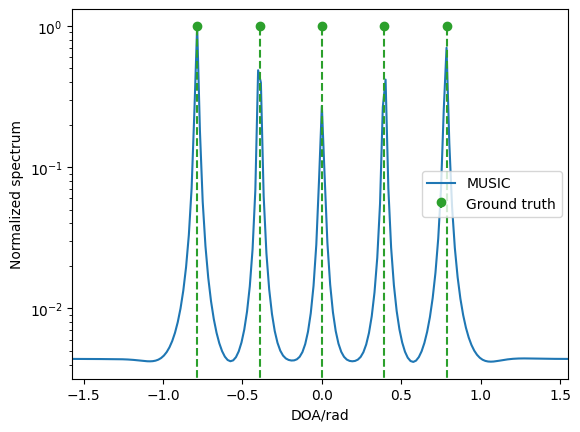

In [ ]:
# Create a MUSIC-based estimator.
grid = estimation.FarField1DSearchGrid()
estimator = estimation.MUSIC(ula, wavelength, grid)
# Get the estimates.
resolved, estimates, sp = estimator.estimate(R, sources.size, return_spectrum=True)
print('MUSIC Estimates: {0}'.format(estimates.locations))
print('Ground truth: {0}'.format(sources.locations))

# Plot the MUSIC-spectrum.
doaplot.plot_spectrum({'MUSIC': sp}, grid, ground_truth=sources, use_log_scale=True)

## ESPRIT estimation

In [4]:
# Create a ESPRIT-based estimator.
estimator = estimation.Esprit1D(wavelength)
# Get the estimates.
resolved, estimates = estimator.estimate(R, sources.size, d0)
print('ESPRIT Estimates: {0}'.format(np.rad2deg(estimates.locations)))
print('Ground truth: {0}'.format(np.rad2deg(sources.locations)))


ESPRIT Estimates: [-4.54802466e+01 -2.24655585e+01 -1.20873102e-03  2.24343493e+01
  4.48215767e+01]
Ground truth: [-45.  -22.5   0.   22.5  45. ]


## Beamforming estimation

In [5]:
grid = estimation.FarField1DSearchGrid()
# MVDR
mvdr = estimation.MVDRBeamformer(ula, wavelength, grid)
resolved, estimates = mvdr.estimate(R, sources.size)
print("MVDR Estimates: {0}".format(np.rad2deg(estimates.locations)))
# Bartlett
bartlett = estimation.BartlettBeamformer(ula, wavelength, grid)
resolved, estimates = bartlett.estimate(R, sources.size)
print("Bartlett Estimates: {0}".format(np.rad2deg(estimates.locations)))

print("Ground truth: {0}".format(np.rad2deg(sources.locations)))


MVDR Estimates: [-45. -23.   0.  23.  45.]
Bartlett Estimates: [-45. -23.   0.  23.  45.]
Ground truth: [-45.  -22.5   0.   22.5  45. ]


## MinNorm Estimates

Min-Norm Estimates: [-45. -23.   0.  23.  45.]


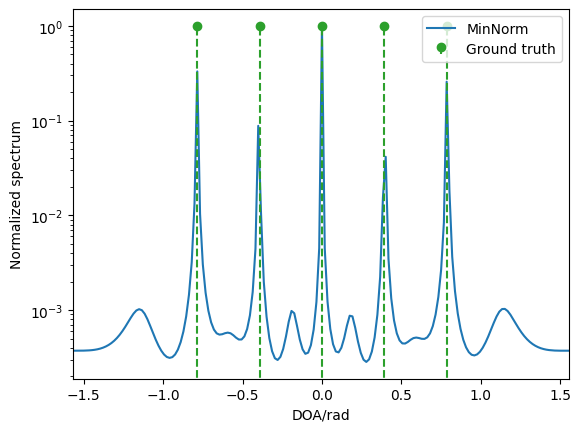

In [6]:
grid = estimation.FarField1DSearchGrid()
mininorm = estimation.MinNorm(ula, wavelength, grid)  
resolved, estimates, sp = mininorm.estimate(R, sources.size,return_spectrum=True)
print("Min-Norm Estimates: {0}".format(np.rad2deg(estimates.locations)))
# Plot the MUSIC-spectrum.
doaplot.plot_spectrum({'MinNorm': sp}, grid, ground_truth=sources, use_log_scale=True);

## Maximum-likelihood Estimates

In [7]:
# 首先使用MUSIC估计器生成初始猜测
grid = estimation.FarField1DSearchGrid()
music_estimator = estimation.MUSIC(ula, wavelength, grid)
_, initial_guess, _ = music_estimator.estimate(R, sources.size, return_spectrum=True)

# 然后使用ML估计器，传入初始猜测
aml = estimation.AMLEstimator(ula, wavelength)
resolved, estimates = aml.estimate(R, initial_guess)
print("Asymptotic maximum-likelihood Estimates: {0}".format(np.rad2deg(estimates.locations)))

cml = estimation.CMLEstimator(ula, wavelength)
resolved, estimates = cml.estimate(R, initial_guess)
print("Conditional maximum-likelihood Estimates: {0}".format(np.rad2deg(estimates.locations)))

wsf = estimation.WSFEstimator(ula, wavelength)
resolved, estimates = wsf.estimate(R, initial_guess)
print("Weighted subspace fitting Estimates: {0}".format(np.rad2deg(estimates.locations)))

print("ground truth: {0}".format(np.rad2deg(sources.locations)))

Asymptotic maximum-likelihood Estimates: [-4.50865503e+01 -2.25451630e+01  1.45054133e-02  2.25912963e+01
  4.48333008e+01]
Conditional maximum-likelihood Estimates: [-4.50878421e+01 -2.25446697e+01  1.34042577e-02  2.25929489e+01
  4.48327584e+01]
Weighted subspace fitting Estimates: [-4.50866075e+01 -2.25470753e+01  1.52918324e-02  2.25920745e+01
  4.48342192e+01]
ground truth: [-45.  -22.5   0.   22.5  45. ]


## Sparse Method

c:\Users\hengxt\miniconda3\envs\doatools\Lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:251: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(


Sparse Covariance Matching Estimates: [-45. -22.   0.  22.  45.]
Group Sparse Estimator Estimates: [-45. -23.   0.  23.  45.]


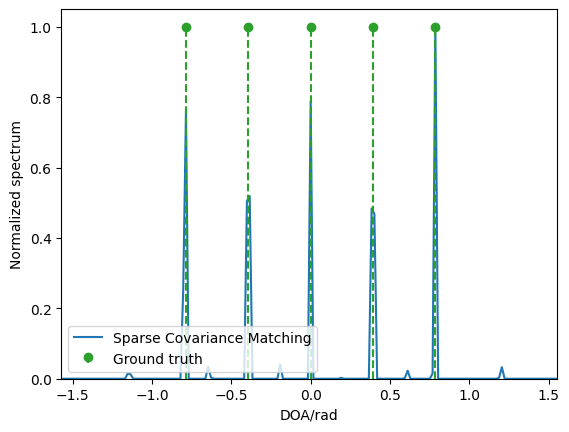

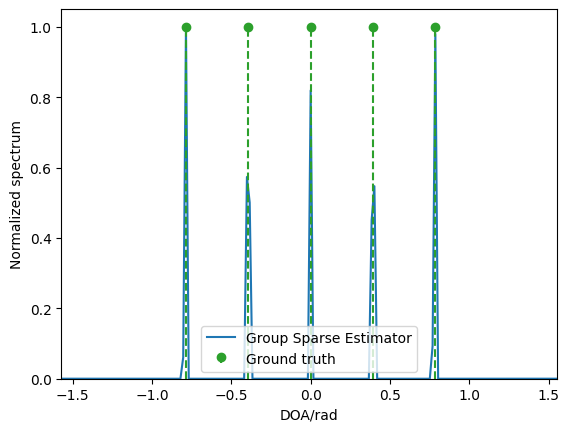

(<Axes: xlabel='DOA/rad', ylabel='Normalized spectrum'>,
 [[<matplotlib.lines.Line2D at 0x229f7d7dee0>],
  <StemContainer object of 3 artists>])

In [8]:
grid = estimation.FarField1DSearchGrid()
scm = estimation.SparseCovarianceMatching(ula, wavelength, grid)
l = 8.0
resolved, estimates, sp_scm = scm.estimate(R, sources.size, l, return_spectrum=True, solver_options={"solver":"SCS"})
print("Sparse Covariance Matching Estimates: {0}".format(np.rad2deg(estimates.locations)))


gse = estimation.GroupSparseEstimator(ula, wavelength, grid, n_snapshots=len(ula.element_indices))
l = 8.0
resolved, estimates, sp_gse = gse.estimate(R, sources.size, l, return_spectrum=True,solver_options={"solver":"SCS"})
print("Group Sparse Estimator Estimates: {0}".format(np.rad2deg(estimates.locations)))


doaplot.plot_spectrum({'Sparse Covariance Matching': sp_scm}, grid, ground_truth=sources)
doaplot.plot_spectrum({'Group Sparse Estimator': sp_gse}, grid, ground_truth=sources)

## Interferometer Method
*Note: The interferometer algorithm can only estimate the DOA of a single signal source, so we need to create a single signal source.*

In [ ]:
single_source = model.FarField1DSourcePlacement([np.pi/6])
source_signal = model.ComplexStochasticSignal(single_source.size, power_source)
signal_matrix = model.get_narrowband_snapshots(
    ula, single_source, wavelength, source_signal, noise_signal, n_snapshots, 
    return_covariance=False
)

interferometer = estimation.Interferometer1D(wavelength)
resolved, estimates = interferometer.estimate(
    signal_matrix, ula.element_locations, unit='deg'
)
if resolved:
    print("Interferometer Estimates (deg): {0}".format(estimates.locations))
    print("Ground truth (deg): {0}".format(np.rad2deg(single_source.locations)))
else:
    print("Interferometer estimation failed.")

Interferometer Estimates (deg): 30.15424044286159
Ground truth (deg): [30.]
